In [1]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn import tree


In [3]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [4]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime"]]

In [32]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]

In [49]:
categorical_cols=data_mat.drop(["Dalc","Walc"],axis=1).columns
data_mat2 = data_mat.drop(["Dalc","Walc"],axis=1)
categorical_cols

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_mat2[col] = le.fit_transform(data_mat2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_mat2.head()

  sex: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  age: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7)}
  address: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  famsize: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  Pstatus: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  Medu: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Fedu: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Mjob: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Fjob: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,3,1,0,0,4,4,0,4,0,...,3,2,3,0,0,2,6,2,3,3
GP,0,2,1,0,1,1,1,0,2,0,...,4,2,2,0,0,2,4,2,2,3
GP,0,0,1,1,1,1,1,0,2,2,...,3,2,1,1,2,2,10,4,5,7
GP,0,0,1,0,1,4,2,1,3,1,...,2,1,1,0,0,4,2,12,11,12
GP,0,1,1,0,1,3,3,2,2,1,...,3,2,1,0,1,4,4,3,7,7


In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier



clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2,
    random_state=0)
scores = cross_val_score(clf, data_mat2, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=0)
scores = cross_val_score(clf, data_mat2, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=1)
scores = cross_val_score(clf, data_mat2, y, cv=5)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899


np.False_

In [55]:
    
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(data_mat2, y, test_size=0.3, random_state=0)

model_0 = DecisionTreeRegressor()
model_6 = LogisticRegression(random_state=1)
model_7 = GaussianNB()
model_1 = SGDClassifier(random_state=1)
model_2 = DecisionTreeClassifier()
model_3 = KNeighborsClassifier(n_neighbors=2)

model_4 = VotingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('lr', model_6),
                            ('gnb', model_7),
                            ('KNN', model_3)],
                          voting='hard')

for model in (model_0, model_1, model_2, model_3, model_4,model_6,model_7):
    model.fit(X_train, y_train)
    print(model.__class__.__name__, model.score(X_test, y_test))
     



DecisionTreeRegressor -0.8788050885960919
SGDClassifier 0.40336134453781514
DecisionTreeClassifier 0.5966386554621849
KNeighborsClassifier 0.6890756302521008
VotingClassifier 0.7058823529411765
LogisticRegression 0.7310924369747899
GaussianNB 0.29411764705882354


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

[Text(0.5039655172413793, 0.9722222222222222, 'x[8] <= 1.5\ngini = 0.496\nsamples = 276\nvalue = [187, 54, 21, 7, 7]'),
 Text(0.2289655172413793, 0.9166666666666666, 'x[4] <= 3.5\ngini = 0.652\nsamples = 72\nvalue = [36, 18, 13, 1, 4]'),
 Text(0.3664655172413793, 0.9444444444444444, 'True  '),
 Text(0.13517241379310344, 0.8611111111111112, 'x[7] <= 17.5\ngini = 0.518\nsamples = 43\nvalue = [28.0, 9.0, 5.0, 1.0, 0.0]'),
 Text(0.06620689655172414, 0.8055555555555556, 'x[5] <= 4.5\ngini = 0.395\nsamples = 33\nvalue = [25, 5, 3, 0, 0]'),
 Text(0.027586206896551724, 0.75, 'x[6] <= 9.0\ngini = 0.133\nsamples = 14\nvalue = [13, 0, 1, 0, 0]'),
 Text(0.016551724137931035, 0.6944444444444444, 'gini = 0.0\nsamples = 10\nvalue = [10, 0, 0, 0, 0]'),
 Text(0.038620689655172416, 0.6944444444444444, 'x[4] <= 2.5\ngini = 0.375\nsamples = 4\nvalue = [3, 0, 1, 0, 0]'),
 Text(0.027586206896551724, 0.6388888888888888, 'gini = 0.0\nsamples = 3\nvalue = [3, 0, 0, 0, 0]'),
 Text(0.0496551724137931, 0.63888888

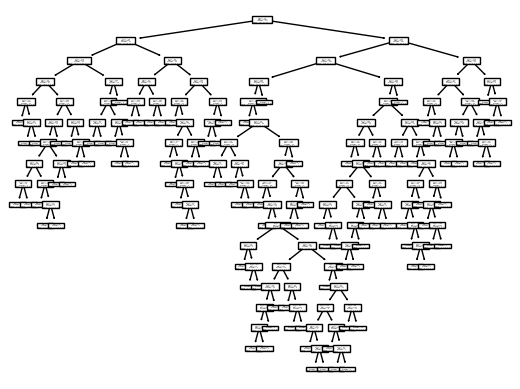

In [8]:
tree.plot_tree(model_2)

In [9]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [10]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)


model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6470588235294118

In [11]:
model = RandomForestClassifier(n_estimators=100, max_depth=3)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [12]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [13]:
best = 0
best_k=0
for k in range (1,100,1):
    model = AdaBoostClassifier(n_estimators=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    if(best<score):
        best=score
        best_k=k
    if(score>0.73):
        print(k,score)
print("best : ",best_k,best)

1 0.7478991596638656
2 0.7478991596638656
3 0.7478991596638656
4 0.7478991596638656
6 0.7478991596638656
7 0.7310924369747899
8 0.7310924369747899
9 0.7310924369747899
10 0.7478991596638656
11 0.7478991596638656
12 0.7478991596638656
18 0.7478991596638656
19 0.7478991596638656
20 0.7394957983193278
23 0.7394957983193278
24 0.7394957983193278
25 0.7394957983193278
27 0.7478991596638656
31 0.7478991596638656
best :  1 0.7478991596638656


In [14]:
model = AdaBoostClassifier(n_estimators=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [15]:
from sklearn.ensemble import StackingClassifier
model = StackingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('KNN', model_3)],
                             final_estimator=DecisionTreeClassifier())

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.25210084033613445